# LTAT.02.006 Andmeteaduse meetodid

## 11. praktikum "Lineaarregressioon".


Selles praktikumis vaatame taaskord iirise andmestikku.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

In [2]:
iris_df = pd.read_csv('iris.csv')
iris_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


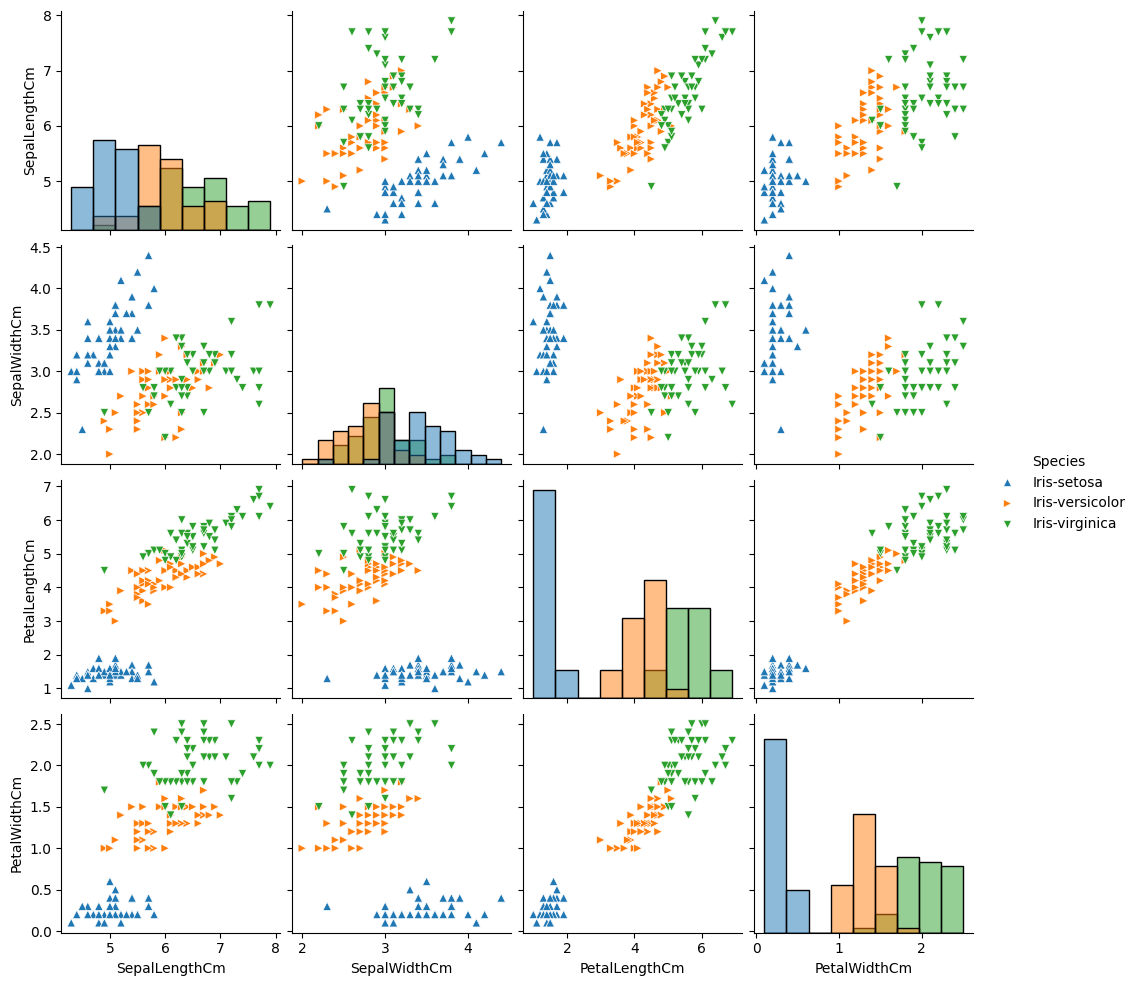

In [3]:
sns.pairplot(iris_df, hue='Species',markers=['^','>','v'], diag_kind="hist")
plt.show()

# 1. ülesanne


Selles ülesandes uurime `statsmodels` teeki, üritades sellega läbi viia mõned lihtsamad lineaarregressiooni näited. `statsmodels` teegil on `formula` API, millega saab mõningaid statistilisi mudeleid vähese vaevaga sobitada R-st inspireeritud valemite kujuga. Valemeid kirjutatakse kujul `y ~ x1 + x2 + 1`, kus `1` viitab sellele, et sobitame ka lõikepunkti `y` teljega. Teise argumendina peab andma sobitamismeetodile andmete `DataFrame`-i. Dokumentatsiooni (küll natuke kasutamatu) leiab siit https://www.statsmodels.org/stable/api.html#statsmodels-formula-api.


1. Selleks, et `statsmodels` mudeleid kasutada, tuleb kõigepealt mudel defineerida ning seejärel see sobitada. Sobitamine annab välja `RegressionResults` objekti, millel on küljes palju kasulikke meetodeid ja atribuute. Uurige neist meetodeid `summary`, `conf_int` ja atribuute `params` ja `fittedvalues`.


In [4]:
mod = smf.ols('PetalWidthCm ~ SepalLengthCm + 1', iris_df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           PetalWidthCm   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     299.2
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.31e-37
Time:                        13:17:37   Log-Likelihood:                -88.862
No. Observations:                 150   AIC:                             181.7
Df Residuals:                     148   BIC:                             187.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -3.2063      0.257    -12.467

In [13]:
res.conf_int(alpha=0.05)

,0,1
Intercept,-3.714514,-2.698040
SepalLengthCm,0.667718,0.839963


In [6]:
res.fittedvalues

0      0.638312
1      0.487543
2      0.336775
3      0.261391
4      0.562928
         ...   
145    1.844457
146    1.542921
147    1.693689
148    1.467537
149    1.241384
Length: 150, dtype: float64

In [7]:
res.params

Intercept       -3.206277
SepalLengthCm    0.753841
dtype: float64

2. Uurime mudeli jääke (ingl. _residuals_) ehk ennustuste ja tegelike väärtuste vahesid. Meetod `predict` annab ennustuse ja kui sellele argumente mitte anda, käib ennustamine treenimisandmete peal.


Paneme ennustused ja jäägid hajuvusdiagrammile.


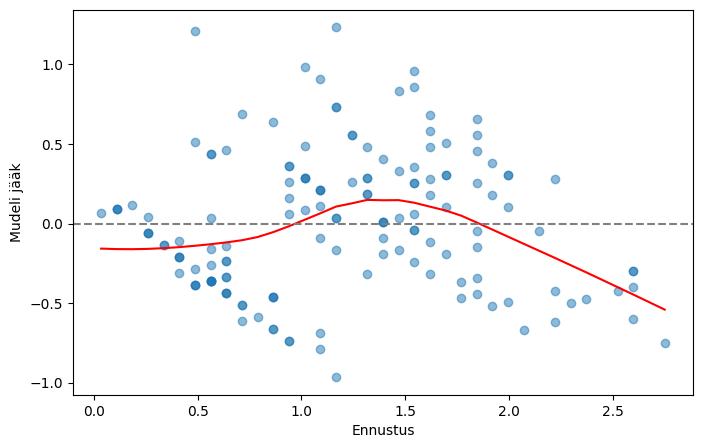

In [8]:
residuals = res.resid

predicted_values = res.predict()

lowess = sm.nonparametric.lowess(residuals, predicted_values)

plt.figure(figsize=(8,5))
plt.scatter(predicted_values, residuals, alpha=0.5)
plt.plot(lowess[:, 0], lowess[:, 1], color='red')

plt.xlabel('Ennustus')
plt.ylabel('Mudeli jääk')
plt.axhline(y=0, color='grey', linestyle='--')
plt.show()

Kontrollime jääkide kvantiile ja võrdleme neid normaaljaotuse kvantiilidega.


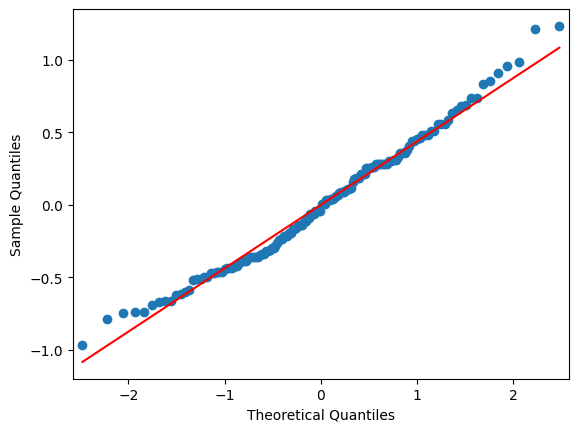

In [9]:
fig = sm.qqplot(residuals, line='s')
plt.show()

3. Rakendage `get_prediction` meetodit. Nii nagu meetod `predict`, ennustab ka see meetod treenimisandmete peal, kui sellele argumente mitte anda. Saadud objektil on olemas selline meetod nagu `summary_frame`, mis sisaldab ennustuse tulemust iga andmepunkti jaoks (tulp `mean`), ennustuse standardviga (`mean_se`), usaldusintervalli ülemine ja alumine piir (`mean_ci_*`) ja prognoosiintervall ülemine ja alumine piir (`obs_ci_*`). Saab muuta ka `alpha` väärtust. Katsetage eri `alpha` väärtustega ning kandke regressioonisirge, tema usaldusintervall ja andmete prognoosiintervallide ülemised ja alumised piirid ühele graafikule koos algsete andmete hajusdiagrammiga.


In [14]:
pred_ols = res.get_prediction()
pred_ols.summary_frame(alpha=0.01)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,0.638312,0.048406,0.511998,0.764626,-0.518112,1.794736
1,0.487543,0.054625,0.345002,0.630085,-0.670765,1.645852
2,0.336775,0.061454,0.176415,0.497136,-0.823861,1.497411
3,0.261391,0.065037,0.091679,0.431103,-0.900574,1.423356
4,0.562928,0.051425,0.428736,0.697119,-0.594383,1.720238
...,...,...,...,...,...,...
145,1.844457,0.051842,1.709178,1.979736,0.687020,3.001894
146,1.542921,0.041107,1.435654,1.650188,0.388422,2.697419
147,1.693689,0.045964,1.573747,1.813631,0.537944,2.849434
148,1.467537,0.039183,1.365290,1.569783,0.313494,2.621580


In [16]:
sf = pred_ols.summary_frame()

In [17]:
def joonista_andmed_ja_mudel(treen_df, test_df, sf):
        plt.scatter(x = treen_df.SepalLengthCm,
                    y = treen_df.PetalWidthCm,
                    color = "green", label = "Algsed andmed")

        plt.xlabel("SepalLengthCm")
        plt.ylabel("PetalWidthCm")

        plt.plot(test_df.SepalLengthCm, sf["mean"],
                 color = "blue", label = "Ennustus")

        plt.plot(test_df.SepalLengthCm, sf["mean_ci_lower"],
                 color = "red", label = "Usaldusintervalli piir")

        plt.plot(test_df.SepalLengthCm, sf["mean_ci_upper"],
                 color = "red")

        plt.plot(test_df.SepalLengthCm, sf["obs_ci_lower"],
                 color = "orange", label = "Prognoosiintervalli piir")

        plt.plot(test_df.SepalLengthCm, sf["obs_ci_upper"],
                 color = "orange")

        plt.legend()
        plt.show()

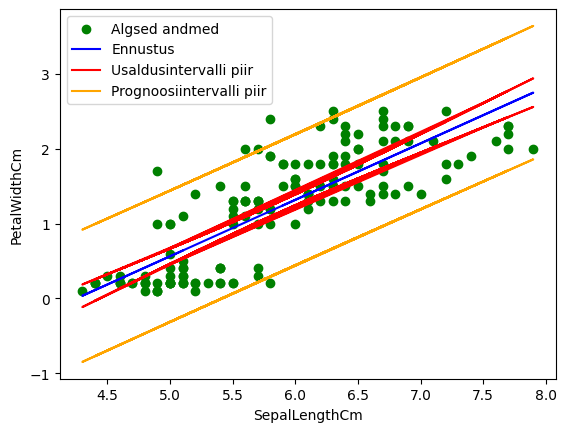

In [18]:
joonista_andmed_ja_mudel(iris_df, iris_df, sf)

4. Viige sama protseduur läbi ka genereeritud andmete peal, kuid ärge rakendage mudelit seekord mitte treeningandmetel, vaid täisarvudel vahemikus (-10, 10). Selleks tuleb mudelile ette anda samade tulpadega andmed, lihtsalt massiivi andmine ei tööta. Nüüd peaks ka `alpha` mõju tugevamini näha olema.


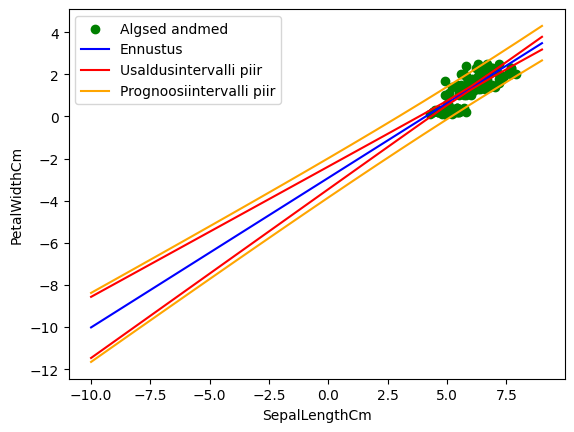

In [25]:
gen_df = pd.DataFrame({
    "SepalLengthCm": np.arange(-10, 10)
})
gen_sf = res.get_prediction(gen_df).summary_frame(alpha=0.1)

joonista_andmed_ja_mudel(iris_df, gen_df, gen_sf)

5. Nüüd jagame meie andmestiku treening ja test andmeteks ning vaatame, kui hästi meie treeningandmetel sobitatud mudel tunnust `PetalWidthCm` ennustab. Selle jaoks, et mudelist ennustusi kätte saada võib kasutada meetodit `mudel.predict(andmed)`. Mudeli headust mõõdame seekord RMSE-ga.


Jaotame andmed:


In [26]:
from sklearn.model_selection import train_test_split

iris_train, iris_test = train_test_split(iris_df, test_size=0.33, random_state=42)

Defineerime RMSE kahte moodi:


In [27]:
def rmse(ennustused, tegelik):
    return np.sqrt(((ennustused - tegelik) ** 2).mean())

In [28]:
from sklearn.metrics import root_mean_squared_error

Sobitame mudeli ja mõõdame headust:


In [24]:
mudel = smf.ols('PetalWidthCm ~ SepalLengthCm + 1', iris_train)
res = mudel.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           PetalWidthCm   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     165.8
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           8.60e-23
Time:                        13:37:49   Log-Likelihood:                -62.941
No. Observations:                 100   AIC:                             129.9
Df Residuals:                      98   BIC:                             135.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.9132      0.324     -8.987

In [ ]:
ennustused = res.predict(iris_test)
rmse_value = rmse(ennustused, iris_test.PetalWidthCm)
print(f"RMSE: {rmse_value}")
rmse_sklearn = root_mean_squared_error(iris_test.PetalWidthCm, ennustused)
print(f"RMSE (sklearn): {rmse_sklearn}")

RMSE: 0.41301720956030624
RMSE (sklearn): 0.41301720956030624


6. Sobitame mudeli uuesti, kuid kasutades kõiki tunnuseid ning mõõdame seejärel taaskord mudeli headust RMSE-ga. Kas tulemus läks paremaks/halvemaks?


In [44]:
mudel = smf.ols('PetalWidthCm ~ SepalLengthCm + SepalWidthCm + PetalLengthCm ', iris_train) # + 1
res = mudel.fit()
#print(res.summary())

In [45]:
ennustused = res.predict(iris_test)
rmse_sklearn = root_mean_squared_error(iris_test.PetalWidthCm, ennustused)
print(f"RMSE (sklearn): {rmse_sklearn}")

RMSE (sklearn): 0.1936260419011416
